In [9]:
pip install pandas matplotlib seaborn scikit-learn statsmodels


Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd

# Load the data
df = pd.read_csv('walmart.csv')

# Check the first few rows
print(df.head())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [11]:
print(df.columns)


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


In [12]:
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
print(df.head())
print(df.columns)


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [13]:
# 1. Strip any whitespace from column names (just in case)
df.columns = df.columns.str.strip()

# 2. Check the first few rows of CustomerID column
print(df['CustomerID'].head())

# 3. Drop rows with missing CustomerID (important for segmentation)
df.dropna(subset=['CustomerID'], inplace=True)


0    17850.0
1    17850.0
2    17850.0
3    17850.0
4    17850.0
Name: CustomerID, dtype: float64


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


In [16]:
print(df.columns.tolist())


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [17]:
# RFM Table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'UnitPrice': 'sum'                                        # Monetary
}).reset_index()

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'UnitPrice': 'Monetary'
}, inplace=True)

print(rfm.head())


   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          2      2.08
1     12347.0        2          7    481.21
2     12348.0       75          4    178.71
3     12349.0       19          1    605.10
4     12350.0      310          1     65.30


In [18]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [19]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)


In [20]:
from sklearn.preprocessing import StandardScaler

# Select features to scale
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Initialize the scaler
scaler = StandardScaler()

# Scale the features
rfm_scaled = scaler.fit_transform(rfm_features)


In [21]:
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [22]:
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)


           CustomerID     Recency   Frequency       Monetary
Cluster                                                     
0        15184.871134   10.752577   28.510309   12168.264691
1        15353.233055  248.927577    1.805942     455.110716
2        15289.090909    5.090909  109.909091  124312.306364
3        15288.256958   42.780906    4.370550    1320.981506


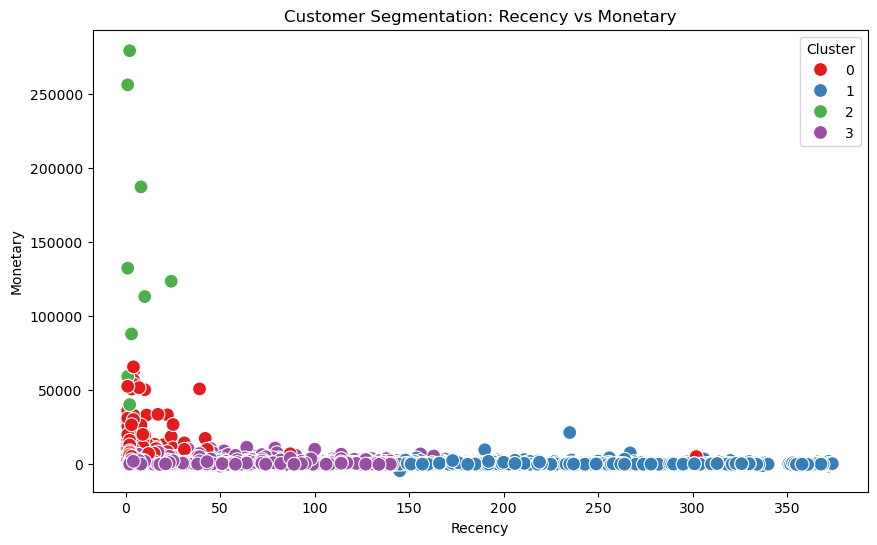

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', s=100)
plt.title('Customer Segmentation: Recency vs Monetary')
plt.show()


In [24]:
# Group by cluster to see actual average RFM values
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).round(1)

print(cluster_summary)


         Recency  Frequency  Monetary  CustomerCount
Cluster                                             
0           10.8       28.5   12168.3            194
1          248.9        1.8     455.1           1077
2            5.1      109.9  124312.3             11
3           42.8        4.4    1321.0           3090


In [25]:
rfm.to_csv('customer_segments.csv', index=False)


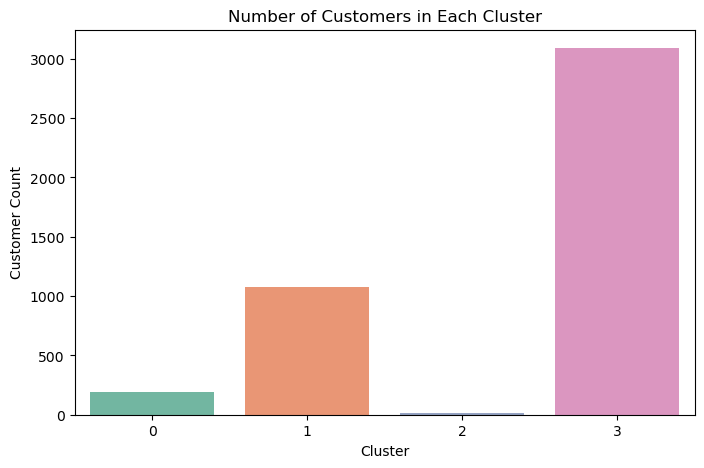

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x='Cluster', hue='Cluster', palette='Set2', legend=False)
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.show()


In [27]:
import pandas as pd

# Load the data
df = pd.read_csv('walmart.csv')

# View the first few rows
print(df.head())

# Check for nulls and data types
print(df.info())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   i

In [28]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')


In [29]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [30]:
from prophet import Prophet

# Filter data for one store (e.g., Store 1)
store_1 = df[df['Store'] == 1]

# Prepare the data for Prophet
store_1_prophet = store_1[['Date', 'Weekly_Sales']].rename(columns={
    'Date': 'ds',
    'Weekly_Sales': 'y'
})

# Initialize the Prophet model
model = Prophet()

# Fit the model on the store's data
model.fit(store_1_prophet)


13:05:32 - cmdstanpy - INFO - Chain [1] start processing
13:05:32 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
import cython
import numpy

print(cython.__version__)
print(numpy.__version__)


3.0.12
1.26.4


In [32]:
from prophet import Prophet


In [33]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt


In [34]:
df = pd.read_csv('walmart.csv')  # Replace with the actual path to your CSV
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [36]:
df['ds'] = pd.to_datetime(df['ds'], dayfirst=True)


In [38]:
df.dtypes


Store                    int64
ds              datetime64[ns]
y                      float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [40]:
# Filter data for Store 1
store_1 = df[df['Store'] == 1][['ds', 'y']]

# Sort by date (just to be safe)
store_1 = store_1.sort_values(by='ds')


In [42]:
from prophet import Prophet  # or from fbprophet import Prophet if you installed that version

# Initialize the model
model = Prophet()

# Fit the model to the store 1 data
model.fit(store_1)


13:06:59 - cmdstanpy - INFO - Chain [1] start processing
13:06:59 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
# Forecast 12 weeks ahead (weekly frequency)
future = model.make_future_dataframe(periods=12, freq='W')


In [46]:
# Predict future sales
forecast = model.predict(future)

# Show the predicted values
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)


,ds,yhat,yhat_lower,yhat_upper
143,2012-10-28,1.533718e+06,1.394334e+06,1.673407e+06
144,2012-11-04,1.599962e+06,1.470262e+06,1.744354e+06
145,2012-11-11,1.690150e+06,1.545833e+06,1.834500e+06
146,2012-11-18,1.747218e+06,1.619373e+06,1.887919e+06
147,2012-11-25,1.768332e+06,1.626352e+06,1.904402e+06
148,2012-12-02,1.810907e+06,1.677056e+06,1.954028e+06
149,2012-12-09,1.913990e+06,1.790885e+06,2.053651e+06
150,2012-12-16,2.024511e+06,1.882945e+06,2.167879e+06
151,2012-12-23,2.026083e+06,1.887979e+06,2.176081e+06
152,2012-12-30,1.856230e+06,1.705968e+06,1.996647e+06


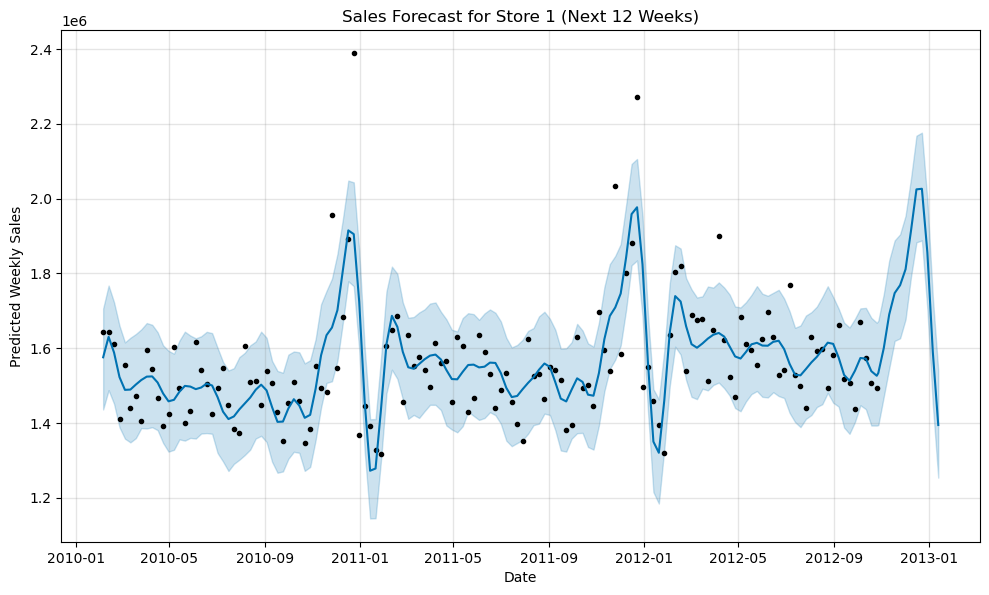

In [48]:
import matplotlib.pyplot as plt

# Plot the forecast
model.plot(forecast)
plt.title("Sales Forecast for Store 1 (Next 12 Weeks)")
plt.xlabel('Date')
plt.ylabel('Predicted Weekly Sales')
plt.show()


In [50]:
# Initialize an empty list to store forecasted data
all_forecasts = []

# Loop through each unique store
for store_id in df['Store'].unique():
    # Filter the data for the current store
    store_data = df[df['Store'] == store_id][['ds', 'y']]
    
    # Sort by date (again, to be safe)
    store_data = store_data.sort_values(by='ds')
    
    # Initialize the Prophet model
    model = Prophet()
    
    # Fit the model
    model.fit(store_data)
    
    # Generate future dataframe for 12 weeks
    future = model.make_future_dataframe(periods=12, freq='W')
    
    # Make the forecast
    forecast = model.predict(future)
    
    # Add the store_id to the forecast dataframe
    forecast['Store'] = store_id
    
    # Append the forecast to the list
    all_forecasts.append(forecast)

# Concatenate all forecasts into a single DataFrame
all_forecasts_df = pd.concat(all_forecasts, ignore_index=True)

# Preview the result
all_forecasts_df[['Store', 'ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)


13:08:30 - cmdstanpy - INFO - Chain [1] start processing
13:08:30 - cmdstanpy - INFO - Chain [1] done processing
13:08:30 - cmdstanpy - INFO - Chain [1] start processing
13:08:30 - cmdstanpy - INFO - Chain [1] done processing
13:08:30 - cmdstanpy - INFO - Chain [1] start processing
13:08:30 - cmdstanpy - INFO - Chain [1] done processing
13:08:31 - cmdstanpy - INFO - Chain [1] start processing
13:08:31 - cmdstanpy - INFO - Chain [1] done processing
13:08:31 - cmdstanpy - INFO - Chain [1] start processing
13:08:31 - cmdstanpy - INFO - Chain [1] done processing
13:08:31 - cmdstanpy - INFO - Chain [1] start processing
13:08:31 - cmdstanpy - INFO - Chain [1] done processing
13:08:31 - cmdstanpy - INFO - Chain [1] start processing
13:08:32 - cmdstanpy - INFO - Chain [1] done processing
13:08:32 - cmdstanpy - INFO - Chain [1] start processing
13:08:32 - cmdstanpy - INFO - Chain [1] done processing
13:08:32 - cmdstanpy - INFO - Chain [1] start processing
13:08:32 - cmdstanpy - INFO - Chain [1]

,Store,ds,yhat,yhat_lower,yhat_upper
6963,45,2012-10-28,7.479082e+05,6.407577e+05,8.499661e+05
6964,45,2012-11-04,7.949898e+05,6.940969e+05,8.912532e+05
6965,45,2012-11-11,8.461215e+05,7.372470e+05,9.463224e+05
6966,45,2012-11-18,8.744613e+05,7.769916e+05,9.758802e+05
6967,45,2012-11-25,9.008877e+05,8.026028e+05,1.003640e+06
6968,45,2012-12-02,9.761171e+05,8.742807e+05,1.080117e+06
6969,45,2012-12-09,1.107868e+06,1.014790e+06,1.209000e+06
6970,45,2012-12-16,1.218938e+06,1.119358e+06,1.320739e+06
6971,45,2012-12-23,1.201042e+06,1.099302e+06,1.306936e+06
6972,45,2012-12-30,1.022328e+06,9.210594e+05,1.118448e+06


In [52]:
# Save the forecasted data to a CSV file
all_forecasts_df.to_csv('store_sales_forecast.csv', index=False)

print("Forecasts saved to store_sales_forecast.csv")


Forecasts saved to store_sales_forecast.csv


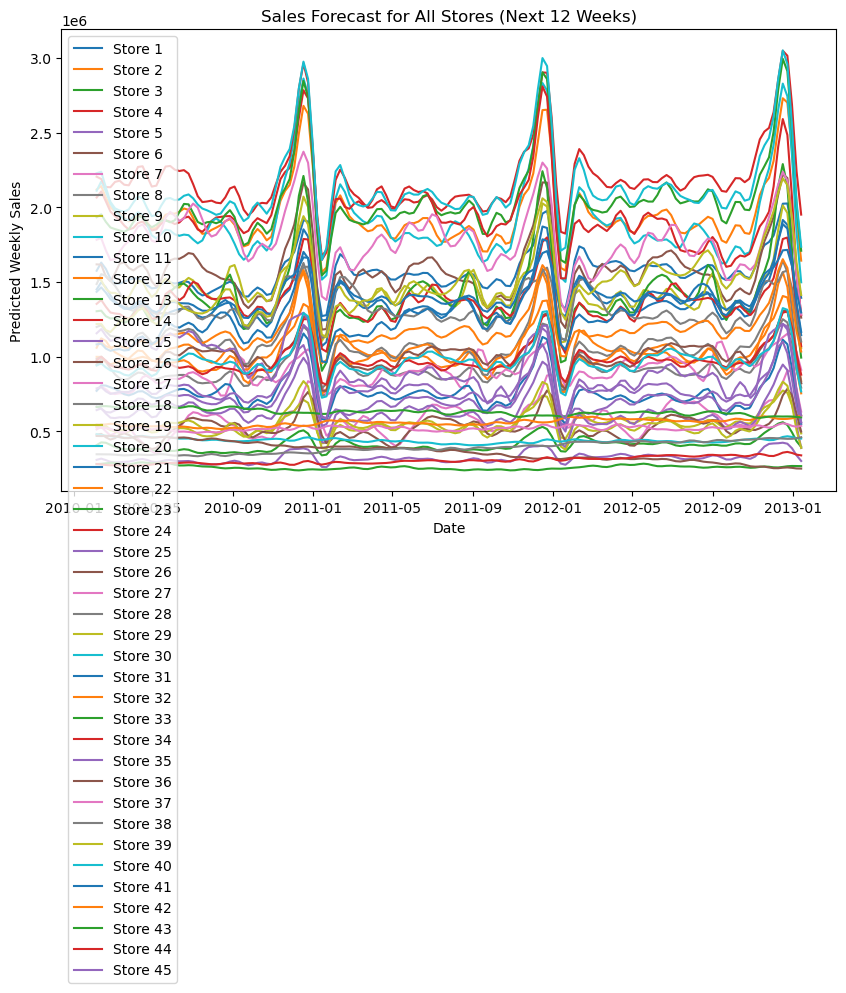

In [54]:
# Plot the forecast for each store
plt.figure(figsize=(10, 6))

for store_id in df['Store'].unique():
    store_forecast = all_forecasts_df[all_forecasts_df['Store'] == store_id]
    plt.plot(store_forecast['ds'], store_forecast['yhat'], label=f"Store {store_id}")

plt.title("Sales Forecast for All Stores (Next 12 Weeks)")
plt.xlabel('Date')
plt.ylabel('Predicted Weekly Sales')
plt.legend()
plt.show()


In [56]:
# Split data into training and test sets (80% training, 20% testing)
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

# Print the split data sizes
print(f"Training data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")


Training data size: 5148
Test data size: 1287


In [66]:
pip install prophet scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [7]:
import os
print(os.getcwd())  


C:\Users\dell


In [9]:
df = pd.read_csv('walmart.csv')
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [13]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.sort_values(by='Date', inplace=True)


In [16]:
store_1 = df[df['Store'] == 1][['Date', 'Weekly_Sales']].copy()
store_1 = store_1.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})


In [18]:
model = Prophet()
model.fit(store_1)


13:31:15 - cmdstanpy - INFO - Chain [1] start processing
13:31:15 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
import os

os.makedirs("forecasts", exist_ok=True)
os.makedirs("models", exist_ok=True)


In [28]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    f"forecasts/store_{store_id}_forecast.csv", index=False
)


In [30]:
store_id = 1
store_data = df[df['Store'] == store_id][['Date', 'Weekly_Sales']].copy()
store_data = store_data.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

model = Prophet()
model.fit(store_data)

future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    f"forecasts/store_{store_id}_forecast.csv", index=False
)


13:34:12 - cmdstanpy - INFO - Chain [1] start processing
13:34:12 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
df = pd.read_csv("online_retail.csv", encoding='ISO-8859-1')  # common encoding for this dataset
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [34]:

df.info()
df.isnull().sum()

df.dropna(subset=['CustomerID', 'Description'], inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['CustomerID'] = df['CustomerID'].astype(str)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [50]:

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'UnitPrice': lambda x: (x * df.loc[x.index, 'Quantity']).sum()  # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'UnitPrice': 'Monetary'
})

rfm = rfm[rfm['Monetary'] > 0]


rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,11,1545.41


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


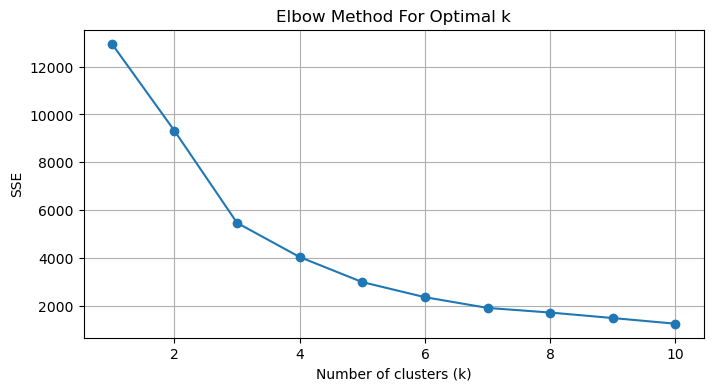

In [42]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE')
plt.grid(True)
plt.show()


In [44]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1
12352.0,36,11,1545.41,0


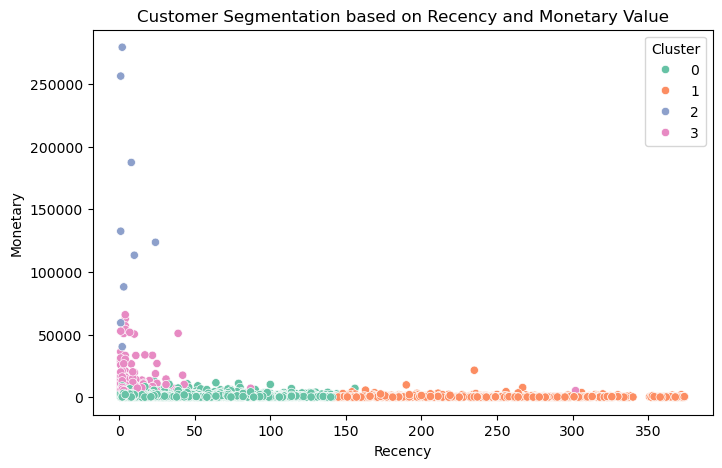

In [46]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Customer Segmentation based on Recency and Monetary Value')
plt.show()


In [48]:

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

cluster_summary.columns = ['Recency_Mean', 'Frequency_Mean', 'Monetary_Mean', 'Customer_Count']
cluster_summary = cluster_summary.sort_values(by='Monetary_Mean', ascending=False)
cluster_summary


,Recency_Mean,Frequency_Mean,Monetary_Mean,Customer_Count
Cluster,,,,
2,5.1,109.9,124312.3,11
3,10.8,28.6,12194.9,193
0,42.2,4.4,1331.3,3061
1,245.6,1.9,490.0,1055
